# This notebook attempts to visualize multisite activation

In [2]:
# Imports and loading of NEURON dll
import numpy as np
from neuron import h
import simulation as sim
import matplotlib.pyplot as plt
import extracellular as ex
import helperFuncs as hf

## Step 1: Setup simualted cell

### Hard reset to delete any lingering segments 

In [3]:
# clear all NEURON sims. Required if you are going to be running many exps
#  in Jupyter notebooks.
for sec in h.allsec():
   h.delete_section(sec=sec)

### Load in simulated cell, real morphologies

In [4]:
RGC = sim.Local_Cell()
filename = 'cell_param_files/params_35_v2.csv'
RGC.build_cell(filename,'mammalian_spike_35')
x_shift = -1000 + 997.8304687738416
RGC.shift_cell_x_y_z(0+x_shift,0,0)

After any change to cell geometry or nseg, be sure to invoke setpointers()


### Uncomment below block if you want to see segment positions

In [5]:
# # Print out (x,y,z) of all the sections and segments 
# for sec in RGC.section_list: 
#     for ii,seg in enumerate(sec):
#         print(sec.name(), ii, seg.xtra.x, seg.xtra.y, seg.xtra.z)

## Step 2: Setup electrical stimulus 

In [6]:
### Most features of the stimulus are set up a struct (dict) called Stim 
Stim = {}

# temporal features of the sitmulus 
Stim['pulseShape'] = 'triphasic'
Stim['dt'] = .005 # units: [ms] # Prev, .005
Stim['delay'] = 10 # units: [ms]
Stim['dur'] = 0.05 # units: [ms]
Stim['stop'] = 50 # units: [ms]
Stim['amp'] = [-0.66,0.91,2.04] # units: [uA]

# calibration phase of the stimulus 
Stim['initDur'] = 50 # units: [ms]
Stim['initDt'] = 1 # units: [ms]
Stim['vInit'] = -70 # units: [mV] #TODO: Old is -70

# spatial features of the stimulus 
# --> specifically defining the electrode geometry 
Stim['electrodes'] = [[-1030,-15,42],[-1015,15,42],[-1000,-15,42]] 
Stim['electrode_type'] = 'disk' # OLD: 'disk'
Stim['rhoExt'] = 1000 # Ohm*cm
Stim['elecDiam'] = 15 # um
Stim['polarity'] = -1 # anodic == 1; cathodic == -1 

Stim['pulseRatioTri'] = [-2/3,1,-1/3]
Stim['pulseRatioBi'] = [1,-1]
Stim['frequency'] = 10 # units: [Hz]

# define transfer impedances 
active_x = [] # Artifact of old code, set as empty
hf.setupTransferImpedance_v3(Stim, RGC, active_x, limit_sites=False)


### Uncomment below to do a current sweet to find threshold 

In [7]:
# thr_c, t_vec, vRec_cathodic = hf.lowerThreshold_v2(Stim, RGC, lower=0, upper=5, num=25, epsilon=0.02)

## Step 3: Figure out which sections are closest to the stimulating electrodes

In [8]:
# Create a dict of segment x,y,z positions
seg_positions = {}
for sec in RGC.section_list:
    # If sec name has 'dend', skip
    if 'dend' in sec.name():
        continue
    else:
        seg_positions[sec.name()] = []
        for seg in sec:
            seg_positions[sec.name()].append([seg.xtra.x,seg.xtra.y,seg.xtra.z])


In [9]:
# For each stimulating electrode, figure out which segment is closest to it
for elec in Stim['electrodes']:
    print('Electrode: ', elec)
    dist_to_elec = np.inf
    for sec in seg_positions:
        for ii,seg in enumerate(seg_positions[sec]):
            dist = np.sqrt((seg[0]-elec[0])**2 + (seg[1]-elec[1])**2 + (seg[2]-elec[2])**2)
            if dist < dist_to_elec:
                dist_to_elec = dist
                seg_id = ii
                closest_seg = [sec,seg_id]
    print('Closest segment: compartment = ', closest_seg[0], ' segID = ', closest_seg[1])
    print('Closest seg coordinates: ', seg_positions[closest_seg[0]][closest_seg[1]])
    print('----------------------------------------------------------------------------')

Electrode:  [-1030, -15, 42]
Closest segment: compartment =  Cell[0].axon  segID =  172
Closest seg coordinates:  [-1029.9999786218007, 0.0, 29.94091033935547]
----------------------------------------------------------------------------
Electrode:  [-1015, 15, 42]
Closest segment: compartment =  Cell[0].axon  segID =  169
Closest seg coordinates:  [-1014.9999784628549, 0.0, 29.94091033935547]
----------------------------------------------------------------------------
Electrode:  [-1000, -15, 42]
Closest segment: compartment =  Cell[0].axon  segID =  166
Closest seg coordinates:  [-999.9999783039091, 0.0, 29.94091033935547]
----------------------------------------------------------------------------


## Step 4: Set up recording vectors before running the stimulation

### Current recording vectors at all segment compartments

In [10]:
# Setup dictionary to capture iOut at all cell compartments
iOut = {}
iOut['axon'] = {}
h.cvode.use_fast_imem(True) # needed for i_membrane_ / extracellular recording
for i,seg in enumerate(RGC.axon):
    iOut['axon']['imem' + str(i)] = h.Vector().record(seg._ref_i_membrane_)

### Voltage recording vectors at all segment compartments 

In [11]:
# set up recording vectors at every axonal segment 
vRec_axon = []
for seg in RGC.axon:
    vRec_axon.append(h.Vector().record(RGC.axon(seg.x)._ref_v))

### Time vector

In [12]:
# set up recoring vector for time in the simulation 
t = h.Vector().record(h._ref_t)

### Record Na membrane current

In [13]:
iNa_axon = []
for seg in RGC.axon:
    iNa_axon.append(h.Vector().record(seg._ref_ina))

## Step 5: Apply stimulus to the cell! 

In [14]:
# Use APCount to detect if an AP occured
APC_axon = h.APCount(1, sec = RGC.axon)
APC_axon.thresh = 0 

# Play the stimulus into the cell, setting it up for stimulation
tsvec, isvec = hf.setupStimulus_unit(Stim)
isvec.play(h._ref_is_xtra, tsvec, 1) 

# Initialization phase of the simulation 
h.init()
h.tstop = Stim['initDur']
h.dt = Stim['initDt']
h.finitialize(Stim['vInit'])
h.continuerun(h.tstop)

# Run the simulation 
h.tstop = Stim['initDur'] + Stim['stop']
h.steps_per_ms = int(1/Stim['dt'])
h.dt = Stim['dt']
h.continuerun(h.tstop)
print('***** sim done *****')

***** sim done *****


## Step 6: Determine point of spike initiation

In [15]:
## -- if spike, increment spike count and record initSeg
spike = 0
min_peaks_inds = []
init_time = np.inf
if APC_axon.n > 0:
    spike_timing = APC_axon.time
    if spike_timing > 50 and spike_timing < 70:
        spike = 1
        print('SPIKE: Currents: ', Stim['amp'], 'uA')
        # Determine where it started
        ### ---- Logic to record spike initiation segment ----
        t_vec = np.array(t)
        vRecord = np.array(vRec_axon)
        # First, truncate out first 50 time samples (initDur)
        vRecord_trunc = vRecord[:,int(Stim['initDur']/Stim['initDt']):]
        t_trunc = t_vec[int(Stim['initDur']/Stim['initDt']):]
        # # Second, truncate initial delay period (delay)
        # vRecord_trunc = vRecord_trunc[:,int((Stim['delay']+Stim['dur']*3+Stim['dt']*3)/Stim['dt']):]
        # t_trunc = t_trunc[int((Stim['delay']+Stim['dur']*3+Stim['dt']*3)/Stim['dt']):]
        # Second, truncate initial delay period (delay)
        # Figure out offset, according to stim_pulse length
        if Stim['pulseShape'] == 'triphasic':
            vRecord_trunc = vRecord_trunc[:,int((Stim['delay']+Stim['dur']*3)/Stim['dt']):]
            t_trunc = t_trunc[int((Stim['delay']+Stim['dur']*3)/Stim['dt']):]
        elif Stim['pulseShape'] == 'monophasic':
            vRecord_trunc = vRecord_trunc[:,int((Stim['delay']+Stim['dur'])/Stim['dt']):]
            t_trunc = t_trunc[int((Stim['delay']+Stim['dur'])/Stim['dt']):]
        elif Stim['pulseShape'] == 'biphasic':
            vRecord_trunc = vRecord_trunc[:,int((Stim['delay']+Stim['dur']*2)/Stim['dt']):]
            t_trunc = t_trunc[int((Stim['delay']+Stim['dur']*2)/Stim['dt']):]
        # --- find max v point ------
        peaks_list = []
        for ii in range(vRecord_trunc.shape[0]):
            vec = vRecord_trunc[ii,:]
            # Find the peaks of the vec waveform 
            # peaks = hf.findPeaks(vec,height=-10,widthSamples=15)
            peaks = hf.findPeaks(vec,height=-10,widthSamples=10)
            if len(peaks) == 0:
                peaks_list.append(np.inf)
            else:
                peaks_list.append(peaks[0])
        
        min_peaks = np.min(peaks_list)
        min_peaks_inds = [i for i, x in enumerate(peaks_list) if x == min_peaks]
        init_time = t_trunc[peaks_list[min_peaks_inds[0]]]
        #### ---------
        # # --- find max v' point ------
        # peaks_list = []
        # for ii in range(vRecord_trunc.shape[0]):
        #     vec = vRecord_trunc[ii,:]
        #     # Find the peaks of the vec waveform 
        #     peak = max_depolarization_rate_sample(vec)
        #     peaks_list.append(peak)
        
        # min_peaks = np.min(peaks_list)
        # min_peaks_inds = [i for i, x in enumerate(peaks_list) if x == min_peaks]
        # init_time = t_trunc[peaks_list[min_peaks_inds[0]]]
        # #### ---------

    else:
        print('SPIKE TIME NOT MET: Currents: ', Stim['amp'], 'uA')
else:
    print('NO SPIKE: Currents: ', Stim['amp'], 'uA')

SPIKE: Currents:  [-0.66, 0.91, 2.04] uA


In [16]:
print(min_peaks_inds)
print(init_time)
print(np.mean(min_peaks_inds))

[161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173]
60.58999999999037
167.0


### Try to plot rx profile (transfer resistance)

In [16]:
transfer_rx = []
for seg in RGC.axon:
    transfer_rx.append(seg.xtra.rx)

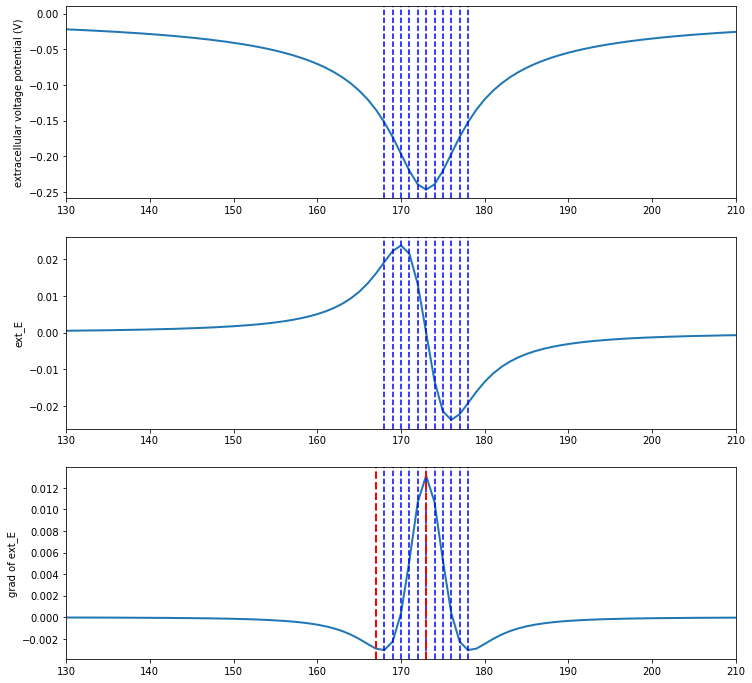

In [17]:
x_seg = np.arange(1,len(transfer_rx)+1)

fig, (ax1,ax2,ax3) = plt.subplots(3,1,figsize=(12,12))

## First, plot V
ax1.plot(x_seg,transfer_rx,linewidth=2)

# Zoom into around the stim elecs
ax1.set_xlim([130,210])
ax1.set_ylabel('extracellular voltage potential (V)')

# Add vertical lines where spike initiation likely occured according to model
for ii in min_peaks_inds:
    ax1.axvline(x=ii+1, color='blue', linestyle='--')

## Now plot dV/dx 
ex_v_prime = -1*np.gradient(transfer_rx)
ax2.plot(x_seg,ex_v_prime,linewidth=2)

# Zoom into around the stim elecs
ax2.set_xlim([130,210])
ax2.set_ylabel('ext_E')

# Add vertical lines where spike initiation likely occured according to model
for ii in min_peaks_inds:
    ax2.axvline(x=ii+1, color='blue', linestyle='--')


## Now plot d2V/dx2
ex_v_prime2 = -1*np.gradient(ex_v_prime)
ax3.plot(x_seg,ex_v_prime2,linewidth=2)

# Zoom into around the stim elecs
ax3.set_xlim([130,210])
ax3.set_ylabel('grad of ext_E')

# Add vertical lines where spike initiation likely occured according to model
for ii in min_peaks_inds:
    ax3.axvline(x=ii+1, color='blue', linestyle='--')

# Add vertical lines at the electrodes 
ax3.axvline(x=173, color='red', linewidth=2, linestyle='--')
ax3.axvline(x=167, color='red', linewidth=2, linestyle='--')


Text(0, 0.5, 'membrane voltage [mV]')

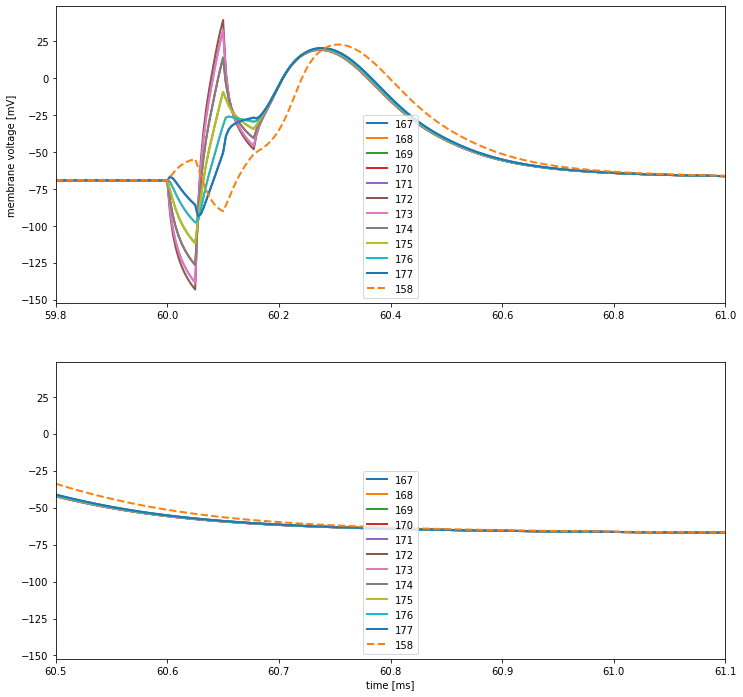

In [18]:
# Plot the actual spike at certain test segments 
fig, (ax,ax2) = plt.subplots(2,1,figsize=(12,12))

# seg1 = 194
# ax.plot(t,vRecord[seg1+1],linewidth=2, color = 'black', label=str(seg1))

# seg2 = 178
# ax.plot(t,vRecord[seg2+1],linewidth=2, color = 'orange', label=str(seg2))

for seg in min_peaks_inds:
    ax.plot(t,vRecord[seg],linewidth=2, label=str(seg))
    ax2.plot(t,vRecord[seg],linewidth=2, label=str(seg))

seg = 158
ax.plot(t,vRecord[seg],linewidth=2,linestyle='--',label=str(seg))
ax2.plot(t,vRecord[seg],linewidth=2,linestyle='--',label=str(seg))

# # Add a vertical line at 60.15 (end of stimulus)
# ax.axvline(x=60.151, color='grey', linestyle='--')

ax.set_xlim([59.8,61])
ax.legend()

ax2.set_xlim([60.5,61.1])
ax2.legend()
ax2.set_xlabel('time [ms]')
ax.set_ylabel('membrane voltage [mV]')

# indx_min = hf.findPeaks(vRecord_trunc[seg2+1],height=-10,widthSamples=10)
# print(indx_min)
# print(t[indx_min[0]])


## Okay, let's try to do threshold finding with triplets

In [19]:
curr1 = -2
curr2 = -1

In [20]:
# Do the threshold search 

# First check if zero current in third elec can cause a spike
currents = [curr1, curr2, 0.00]
# define transfer impedances 
active_x = [-1015] # Old code, this doesn't do anything anymore
hf.setupTransferImpedance_v3(Stim, RGC, active_x, limit_sites=False)
# --- Track spike at axon ---
vRec = []
for seg in RGC.axon:
    vRec.append(h.Vector().record(RGC.axon(seg.x)._ref_v))
t = h.Vector().record(h._ref_t)

## -- run simulation
tsvec, isvec = hf.setupStimulus_unit(Stim)
isvec.play(h._ref_is_xtra, tsvec, 1) 

h.init()
h.tstop = Stim['initDur']
h.dt = Stim['initDt']
h.finitialize(Stim['vInit'])
h.continuerun(h.tstop)

h.tstop = Stim['initDur'] + Stim['stop']
h.steps_per_ms = int(1/Stim['dt'])
h.dt = Stim['dt']
h.continuerun(h.tstop)

upperLim = 5

if (max(vRec[0]) > 0):
    print('Zero current in third electrode can cause a spike')
else:
    current = 0.05
    currents = [curr1, curr2, current] # TODO: Changed 
    # currents = [curr1, curr2, -1*current]
    precision = .4 # %

    firstAP = 0
    stop = False
    while not stop:
        Stim['amp'] = currents

        # define transfer impedances 
        active_x = [-1015] # Old code, this doesn't do anything anymore
        hf.setupTransferImpedance_v3(Stim, RGC, active_x, limit_sites=False)
        
        ## -- set up recording vectors
        APC_axon = h.APCount(1, sec = RGC.axon)
        APC_axon.thresh = 0 

        # --- Track spike at axon ---
        vRec = []
        for seg in RGC.axon:
            vRec.append(h.Vector().record(RGC.axon(seg.x)._ref_v))
        t = h.Vector().record(h._ref_t)

        ## -- run simulation
        tsvec, isvec = hf.setupStimulus_unit(Stim)
        isvec.play(h._ref_is_xtra, tsvec, 1) 

        h.init()
        h.tstop = Stim['initDur']
        h.dt = Stim['initDt']
        h.finitialize(Stim['vInit'])
        h.continuerun(h.tstop)

        h.tstop = Stim['initDur'] + Stim['stop']
        h.steps_per_ms = int(1/Stim['dt'])
        h.dt = Stim['dt']
        h.continuerun(h.tstop)
        
        # Check to see if we see a spike 
        if firstAP == 0:
            if (max(vRec[0]) < 0):
                current = current * 1.5
            else:
                firstAP = 1
                stepCurr = current / 4
                current = current - stepCurr
                # vRecord = np.array(vRec)
        else:
            if (max(vRec[0]) > 0 and stepCurr <= current*precision/100):
                stop = True
                vRecord = np.array(vRec)
            if (max(vRec[0]) > 0 and stepCurr > current*precision/100):
                stepCurr = stepCurr / 2
                current = current - stepCurr 
                vRecord = np.array(vRec)
            if (max(vRec[0]) < 0 and stepCurr > current*precision/100):
                stepCurr = stepCurr / 2
                current = current + stepCurr
            if (max(vRec[0]) < 0 and stepCurr <= current*precision/100):
                current = current + stepCurr
        
        if current > upperLim:
            stop = True
        
        currents = [curr1, curr2, current] # TODO: Changed 
        # currents = [curr1, curr2, -1*current]

if current < upperLim:
    threshold = currents[2]
else:
    threshold = np.nan

if threshold == np.nan:
    print('threshold not found') 
else:
    print(curr1, curr2, threshold)

Zero current in third electrode can cause a spike


NameError: name 'current' is not defined

## Okay, let's do radial sampling in 2D

In [91]:
def radial_vectors(num_samples):
    # Define the angles for each sample
    angles = np.linspace(0, 2 * np.pi, num_samples, endpoint=False)
    
    # Compute the unit vectors
    unit_vectors = np.column_stack((np.cos(angles), np.sin(angles)))
    
    return unit_vectors

In [94]:
num_samples = 300
unit_vectors = radial_vectors(num_samples) * 0.5
print(unit_vectors)

[[ 5.00000000e-01  0.00000000e+00]
 [ 4.99890342e-01  1.04712099e-02]
 [ 4.99561415e-01  2.09378269e-02]
 [ 4.99013364e-01  3.13952598e-02]
 [ 4.98246430e-01  4.18389217e-02]
 [ 4.97260948e-01  5.22642316e-02]
 [ 4.96057351e-01  6.26666168e-02]
 [ 4.94636166e-01  7.30415143e-02]
 [ 4.92998019e-01  8.33843734e-02]
 [ 4.91143625e-01  9.36906573e-02]
 [ 4.89073800e-01  1.03955845e-01]
 [ 4.86789451e-01  1.14175435e-01]
 [ 4.84291581e-01  1.24344944e-01]
 [ 4.81581283e-01  1.34459910e-01]
 [ 4.78659749e-01  1.44515898e-01]
 [ 4.75528258e-01  1.54508497e-01]
 [ 4.72188185e-01  1.64433323e-01]
 [ 4.68640995e-01  1.74286024e-01]
 [ 4.64888243e-01  1.84062276e-01]
 [ 4.60931576e-01  1.93757793e-01]
 [ 4.56772729e-01  2.03368322e-01]
 [ 4.52413526e-01  2.12889646e-01]
 [ 4.47855880e-01  2.22317590e-01]
 [ 4.43101790e-01  2.31648018e-01]
 [ 4.38153340e-01  2.40876837e-01]
 [ 4.33012702e-01  2.50000000e-01]
 [ 4.27682130e-01  2.59013505e-01]
 [ 4.22163963e-01  2.67913397e-01]
 [ 4.16460620e-01  2

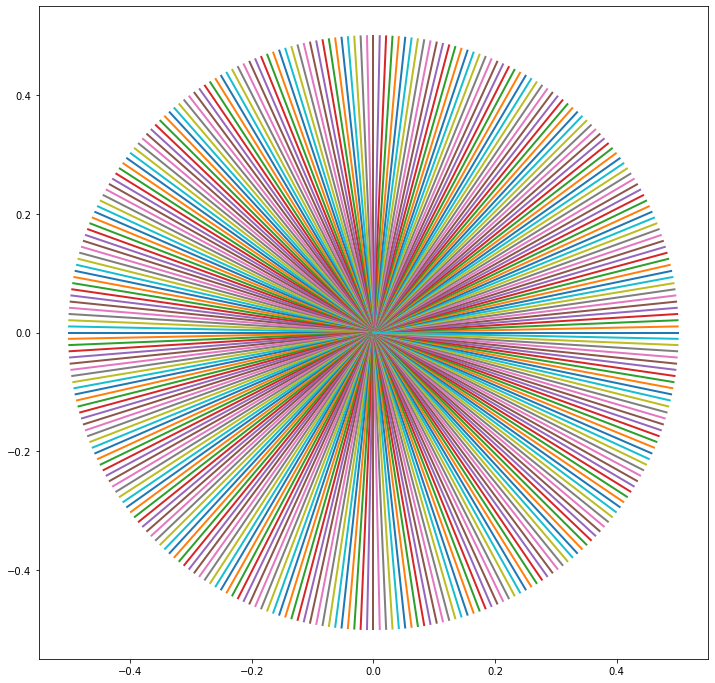

In [95]:
# plot line from origin to point represented by unit_vectors
fig, ax = plt.subplots(figsize=(12,12))
for vec in unit_vectors:
    ax.plot([0,vec[0]],[0,vec[1]],linewidth=2)
    


In [81]:
unit_curr_dir = unit_vectors[75]
print(unit_curr_dir)

[1.41638472e-16 5.00000000e-01]


In [82]:
### --- setup stimulus
Stim = {}

Stim['pulseShape'] = 'triphasic'
Stim['dt'] = .005 # TODO: Changed from .005
Stim['delay'] = 10
Stim['dur'] = 0.05 # [ms]
Stim['stop'] = 70

Stim['initDur'] = 50
Stim['initDt'] = 1
Stim['vInit'] = -70 # units: [mV]

Stim['electrodes'] = [[-1030,0,42],[-1000,0,42]]
Stim['electrode_type'] = 'disk'
Stim['rhoExt'] = 1000 # Ohm*cm
Stim['elecDiam'] = 15 # um
Stim['polarity'] = -1 # anodic == 1; cathodic == -1 

Stim['pulseRatioTri'] = [-2/3,1,-1/3]
Stim['pulseRatioBi'] = [1,-1]
Stim['frequency'] = 10 # units: [Hz]

In [83]:
# Implement a bisection search to find the optimal scaling factor
epsilon = 0.1
lowBound = 1
upBound = 10
stop = False
scale_factor = np.nan

while not stop:
    print('LowBound: ', lowBound, ' UpBound: ', upBound)
    scaling_factor = lowBound + ((upBound - lowBound) / 2)
    print('Testing: ',scaling_factor)
    currents = unit_curr_dir * scaling_factor
    Stim['amp'] = currents

    # Run simulation
    active_x = [-1015] # Old code, this doesn't do anything anymore
    hf.setupTransferImpedance_v3(Stim, RGC, active_x, limit_sites=False)
    # --- Track spike at axon ---
    vRec = []
    for seg in RGC.axon:
        vRec.append(h.Vector().record(RGC.axon(seg.x)._ref_v))
    t = h.Vector().record(h._ref_t)

    ## -- run simulation
    tsvec, isvec = hf.setupStimulus_unit(Stim)
    isvec.play(h._ref_is_xtra, tsvec, 1) 

    h.init()
    h.tstop = Stim['initDur']
    h.dt = Stim['initDt']
    h.finitialize(Stim['vInit'])
    h.continuerun(h.tstop)

    h.tstop = Stim['initDur'] + Stim['stop']
    h.steps_per_ms = int(1/Stim['dt'])
    h.dt = Stim['dt']
    h.continuerun(h.tstop)

    # Detect whether spike happened and update bounds
    if (max(vRec[0]) > 0):
        print('Spike detected')
        upBound = scaling_factor
        precision = upBound - lowBound
        vRecord = np.array(vRec)
        scale_factor = scaling_factor
    else:
        lowBound = scaling_factor
        precision = upBound - lowBound

    # Figure out if I should escape
    if precision < epsilon:
        stop = True

LowBound:  1  UpBound:  10
Testing:  5.5
Spike detected
LowBound:  1  UpBound:  5.5
Testing:  3.25
LowBound:  3.25  UpBound:  5.5
Testing:  4.375
Spike detected
LowBound:  3.25  UpBound:  4.375
Testing:  3.8125
Spike detected
LowBound:  3.25  UpBound:  3.8125
Testing:  3.53125
Spike detected
LowBound:  3.25  UpBound:  3.53125
Testing:  3.390625
Spike detected
LowBound:  3.25  UpBound:  3.390625
Testing:  3.3203125
Spike detected


In [87]:
print(scale_factor)

3.3203125


## Now, let's try radial sampling in 3D

In [22]:
## -- First, compile a list of t, thetha directions you want to travel

# Endpoints of the line
r0 = np.array([-3, 4, -2.7])
r1 = np.array([3.5, -4, 3])

# Direction vector
d = r1 - r0

# Normalize direction vector
d_unit = d / np.linalg.norm(d)

# Find two perpendicular vectors using Gram-Schmidt process
u = np.cross(d_unit, np.array([1, 0, 0]))
if np.linalg.norm(u) == 0:  # if d_unit is parallel to [1, 0, 0]
    u = np.cross(d_unit, np.array([0, 1, 0]))
u = u / np.linalg.norm(u)
v = np.cross(d_unit, u)

# Parameters for sampling
num_samples_along_line = 30
num_radial_samples = 30

# Generate samples
samples = []
t_values = np.linspace(0, 1, num_samples_along_line)
theta_values = np.linspace(0, 2 * np.pi, num_radial_samples)

# Create array of (r_t, theta) tuples
samples = []
for t in t_values:
    r_t = (1 - t) * r0 + t * r1
    for theta in theta_values:
        samples.append([r_t, theta])

900


In [25]:
### --- setup stimulus
Stim = {}

Stim['pulseShape'] = 'triphasic'
Stim['dt'] = .005 # TODO: Changed from .005
Stim['delay'] = 10
Stim['dur'] = 0.05 # [ms]
Stim['stop'] = 70

Stim['initDur'] = 50
Stim['initDt'] = 1
Stim['vInit'] = -70 # units: [mV]

Stim['electrodes'] = [[-1030,-15,42],[-1015,15,42],[-1000,-15,42]]
Stim['electrode_type'] = 'disk'
Stim['rhoExt'] = 1000 # Ohm*cm
Stim['elecDiam'] = 15 # um
Stim['polarity'] = -1 # anodic == 1; cathodic == -1 

Stim['pulseRatioTri'] = [-2/3,1,-1/3]
Stim['pulseRatioBi'] = [1,-1]
Stim['frequency'] = 10 # units: [Hz]

In [29]:
# Conduct threshold search to find the optimal radial distance (r)

# Isolate one direction to search
sample = samples[0]

# Implement a bisection search to find the optimal scaling factor
epsilon = 0.1
lowBound = 0.8
upBound = 10
stop = False
scale_factor = np.nan

while not stop:
    print('LowBound: ', lowBound, ' UpBound: ', upBound)
    scaling_factor = lowBound + ((upBound - lowBound) / 2)
    print('Testing: ',scaling_factor)
    # currents = unit_curr_dir * scaling_factor
    # Define currents 
    r_t = sample[0]
    theta = sample[1]
    currents = r_t + scaling_factor * (np.cos(theta) * u + np.sin(theta) * v)
    Stim['amp'] = currents

    # Run simulation
    active_x = [-1015] # Old code, this doesn't do anything anymore
    hf.setupTransferImpedance_v3(Stim, RGC, active_x, limit_sites=False)
    # --- Track spike at axon ---
    vRec = []
    for seg in RGC.axon:
        vRec.append(h.Vector().record(RGC.axon(seg.x)._ref_v))
    t = h.Vector().record(h._ref_t)

    ## -- run simulation
    tsvec, isvec = hf.setupStimulus_unit(Stim)
    isvec.play(h._ref_is_xtra, tsvec, 1) 

    h.init()
    h.tstop = Stim['initDur']
    h.dt = Stim['initDt']
    h.finitialize(Stim['vInit'])
    h.continuerun(h.tstop)

    h.tstop = Stim['initDur'] + Stim['stop']
    h.steps_per_ms = int(1/Stim['dt'])
    h.dt = Stim['dt']
    h.continuerun(h.tstop)

    # Detect whether spike happened and update bounds
    if (max(vRec[0]) > 0):
        print('Spike detected')
        upBound = scaling_factor
        precision = upBound - lowBound
        vRecord = np.array(vRec)
        scale_factor = scaling_factor
    else:
        lowBound = scaling_factor
        precision = upBound - lowBound

    # Figure out if I should escape
    if precision < epsilon:
        stop = True

LowBound:  1  UpBound:  10
Testing:  5.5
Spike detected
LowBound:  1  UpBound:  5.5
Testing:  3.25
Spike detected
LowBound:  1  UpBound:  3.25
Testing:  2.125
Spike detected
LowBound:  1  UpBound:  2.125
Testing:  1.5625
Spike detected
LowBound:  1  UpBound:  1.5625
Testing:  1.28125
LowBound:  1.28125  UpBound:  1.5625
Testing:  1.421875
LowBound:  1.421875  UpBound:  1.5625
Testing:  1.4921875
Spike detected


In [30]:
print(scale_factor)
print(r_t + scale_factor * (np.cos(theta) * u + np.sin(theta) * v))
print(r_t + 1 * (np.cos(theta) * u + np.sin(theta) * v))

1.4921875
[-3.          4.86587879 -1.48473153]
[-3.          4.58027479 -1.88557924]


## Same thing but sample along 2D line segment

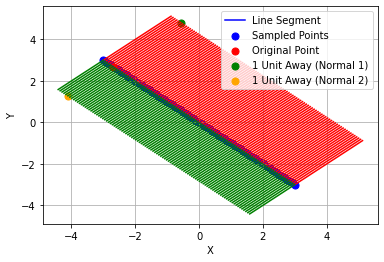

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Define the endpoints of the line segment
A = np.array([-3, 3])
B = np.array([3, -3])

# Calculate the direction vector
d = B - A

# Calculate the normal vectors (perpendicular to direction vector)
n1 = np.array([-(B[1] - A[1]), B[0] - A[0]])  # Normal vector 1
n2 = np.array([B[1] - A[1], -(B[0] - A[0])])  # Normal vector 2

# Normalize the normal vectors
n1 = n1 / np.linalg.norm(n1)
n2 = n2 / np.linalg.norm(n2)

# Generate points along the line segment
t_values = np.linspace(0, 1, 100)
points = np.array([(1 - t) * A + t * B for t in t_values])

# Calculate points 1 unit away in the direction of the normal vectors
points_n1 = points + n1 * 3
points_n2 = points + n2 * 2

# Plotting
fig, ax = plt.subplots()
ax.plot([A[0], B[0]], [A[1], B[1]], 'b-', label='Line Segment')
ax.scatter(points[:, 0], points[:, 1], color='blue', s=50, label='Sampled Points')

# Plot the normal vectors
for i in range(len(points)):
    ax.plot([points[i, 0], points_n1[i, 0]], [points[i, 1], points_n1[i, 1]], 'r-')
    ax.plot([points[i, 0], points_n2[i, 0]], [points[i, 1], points_n2[i, 1]], 'g-')

# Highlight one specific normal vector for clarity
index = 5  # Choose any index from 0 to len(points)-1
ax.scatter(points[index, 0], points[index, 1], color='red', s=50, label='Original Point')
ax.scatter(points_n1[index, 0], points_n1[index, 1], color='green', s=50, label='1 Unit Away (Normal 1)')
ax.scatter(points_n2[index, 0], points_n2[index, 1], color='orange', s=50, label='1 Unit Away (Normal 2)')

# Labels and legend
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.legend()
ax.grid(True)

plt.show()

In [27]:
print(points[0])
print(points[0]+n1)
print(points[0]+n2)

[-3.  3.]
[-2.29289322  3.70710678]
[-3.70710678  2.29289322]
